Overall Accuracy: 79.06%
This means the model correctly predicts good or bad wine about 79.06% of the time.

Confusion Matrix:
             Predicted Bad  Predicted Good
Actual Bad             107              34
Actual Good             33             146

Classification Report:
              precision    recall  f1-score   support

    Bad Wine       0.76      0.76      0.76       141
   Good Wine       0.81      0.82      0.81       179

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.79      0.79      0.79       320


Feature Importance:
                 Feature  Importance
10               alcohol    0.191171
9              sulphates    0.130427
1       volatile acidity    0.106271
6   total sulfur dioxide    0.095007
7                density    0.089647
4              chlorides    0.074499
0          fixed acidity    0.069192
2            citric acid    0.065843
8                     pH    0.065499
5 

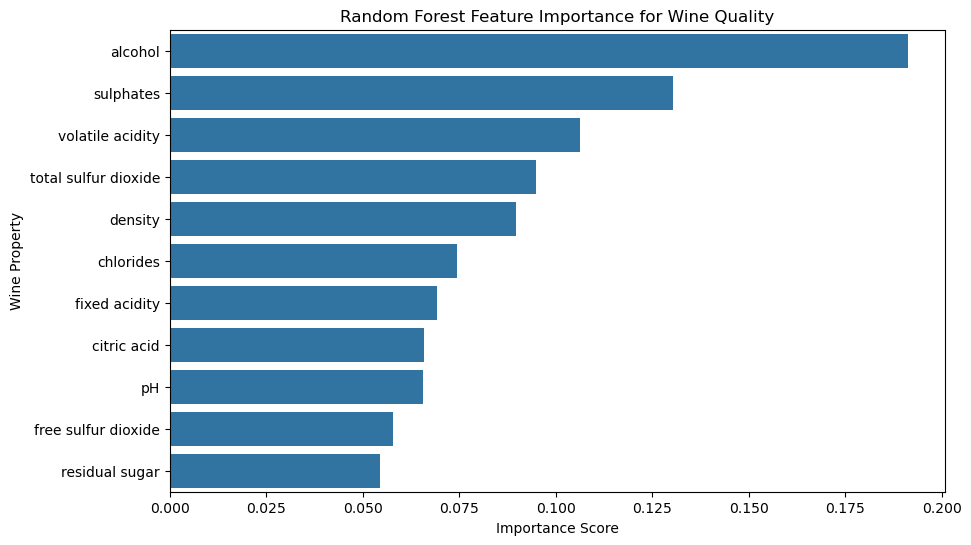

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load dataset from UCI
# -----------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

# -----------------------------
# 2. Convert quality to binary class
# -----------------------------
# Good wine (1) if quality >= 6, else Bad wine (0)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

# -----------------------------
# 3. Split features and target
# -----------------------------
X = data.drop('quality', axis=1)
y = data['quality']

# -----------------------------
# 4. Split training and testing sets
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# -----------------------------
# 6. Predict on test set
# -----------------------------
y_pred = rf.predict(X_test)

# -----------------------------
# 7. Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print("This means the model correctly predicts good or bad wine about {:.2f}% of the time.".format(accuracy*100))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Bad', 'Actual Good'], columns=['Predicted Bad', 'Predicted Good'])
print("\nConfusion Matrix:")
print(cm_df)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad Wine', 'Good Wine']))

# -----------------------------
# 8. Feature importance
# -----------------------------
importances = rf.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_df)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Random Forest Feature Importance for Wine Quality")
plt.xlabel("Importance Score")
plt.ylabel("Wine Property")
plt.show()